## Technique: Model Persistence using joblib

Definition

Model Persistence is the process of saving a trained machine learning model to disk so that it can be loaded later without retraining.

In Scikit-learn, the most commonly used library is joblib, which efficiently serializes Python objects such as models, transformers, pipelines, and hyperparameters.

Why Save a Model?

Training complex models (Random Forest, XGBoost, CatBoost, etc.) can take several minutes or even hours.

Instead of retraining every time,

Train Once -> Save Model (.pkl) -> Load Anytime -> Predict Immediately

In [42]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV,StratifiedKFold
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

In [50]:
iris=load_iris()
X=iris.data
y=iris.target
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,stratify=y)
## stratify=y ensures that both your training and testing sets have the exact same proportion of class labels (e.g., 0s and 1s) as your original dataset.

In [51]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Saving a model

In [52]:
joblib.dump(model,'random_forest.pkl')

['random_forest.pkl']

## Loading a Model

In [53]:
loaded_model=joblib.load('random_forest.pkl')

In [54]:
loaded_model.predict(X_test)

array([0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1, 2, 1, 1, 0, 0, 0, 1, 0, 1, 2, 1,
       1, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 1])

## Saving Multiple Objects

## Model

In [55]:
joblib.dump(model,'random_forest.pkl')

['random_forest.pkl']

## Hyperparameters

In [56]:
best_params=model.get_params()
joblib.dump(best_params,'params.pkl')

['params.pkl']

## Feature Names

In [57]:
# Load the dataset directly as a DataFrame
iris=load_iris(as_frame=True)
df=iris.frame
features=df.columns

joblib.dump(features,'features.pkl')

['features.pkl']

## Technique: Checkpointing (Intermediate Saving)

Checkpointing is the process of periodically saving intermediate results during long-running computations so that work can resume if interrupted.

Instead of -> Train (5 hours) -> Crash -> Restart

we get

Batch 1 ✓ (Save)

Batch 2 ✓ (Save)

Batch 3 (Crash)

Resume from Batch 3

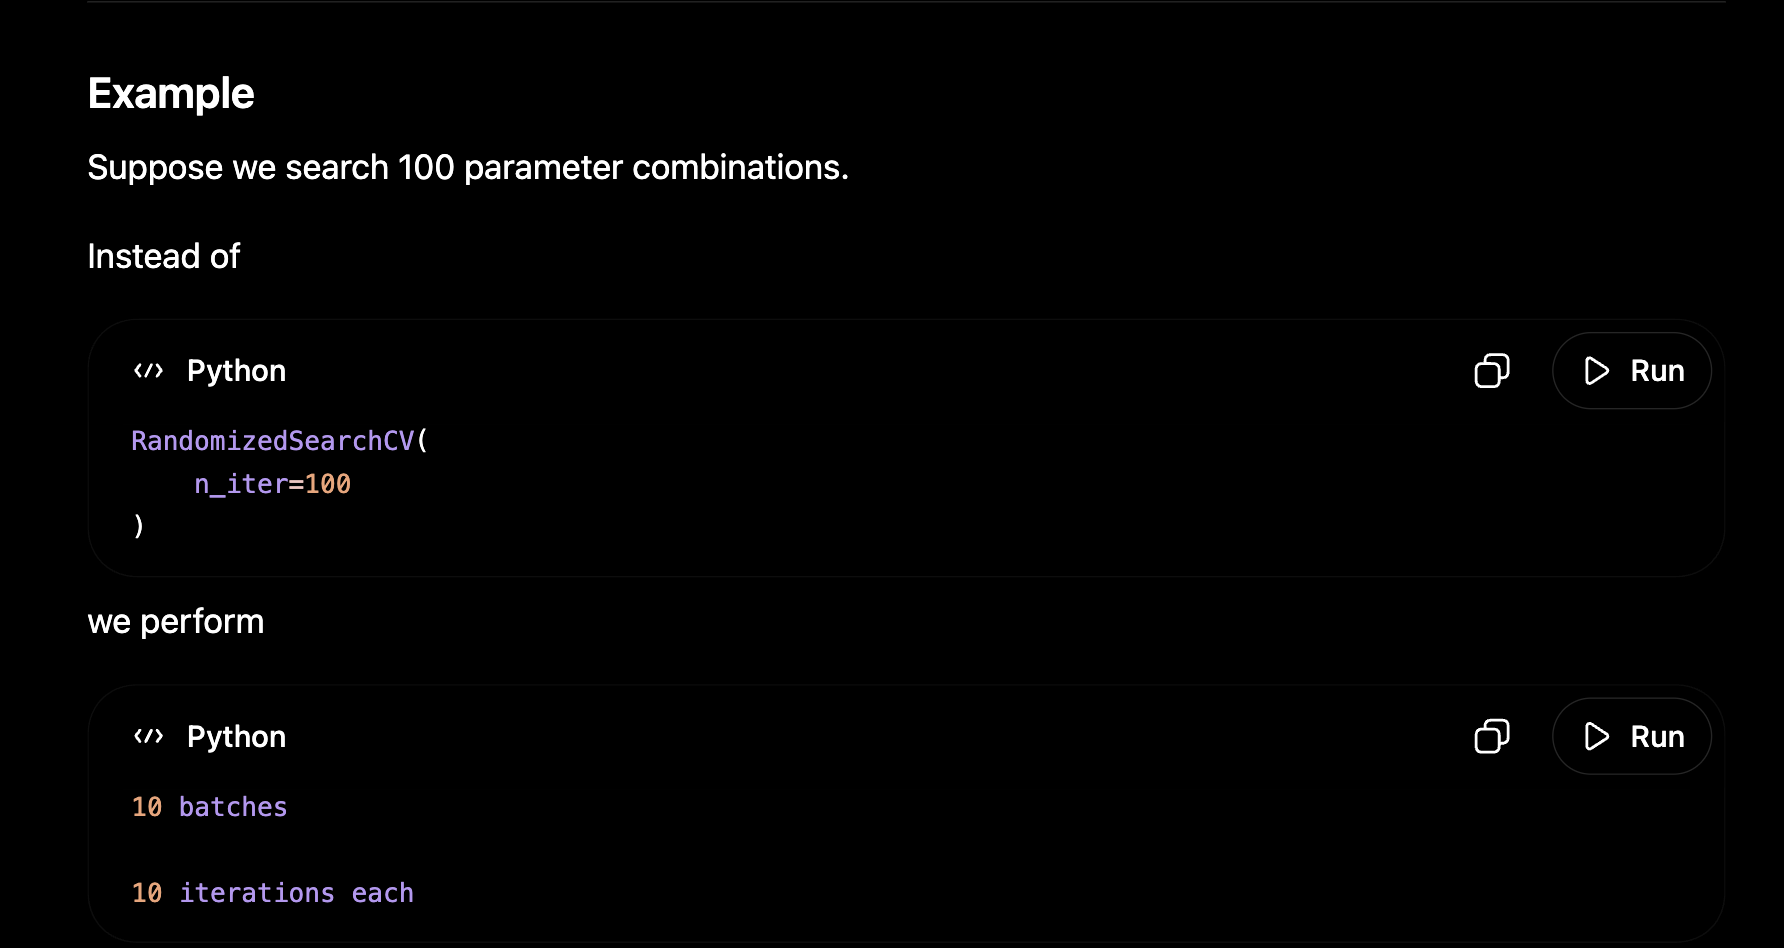

## Check whether model already exist

In [58]:
model_path='random_forest.pkl'
param_path='params.pkl'
if os.path.exists(model_path):
    print("Model already exists.")
    best_model=joblib.load(model_path)
    best_params=joblib.load(param_path)
    print("\n Loaded Parameters")
    print(best_params)
else:
    print("No saved model found.")
    print("Starting Hyperparameter search.")

Model already exists.

 Loaded Parameters
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


## How the data is split → StratifiedKFold

## Which hyperparameters to try → param_grid




## StratifiedKFold
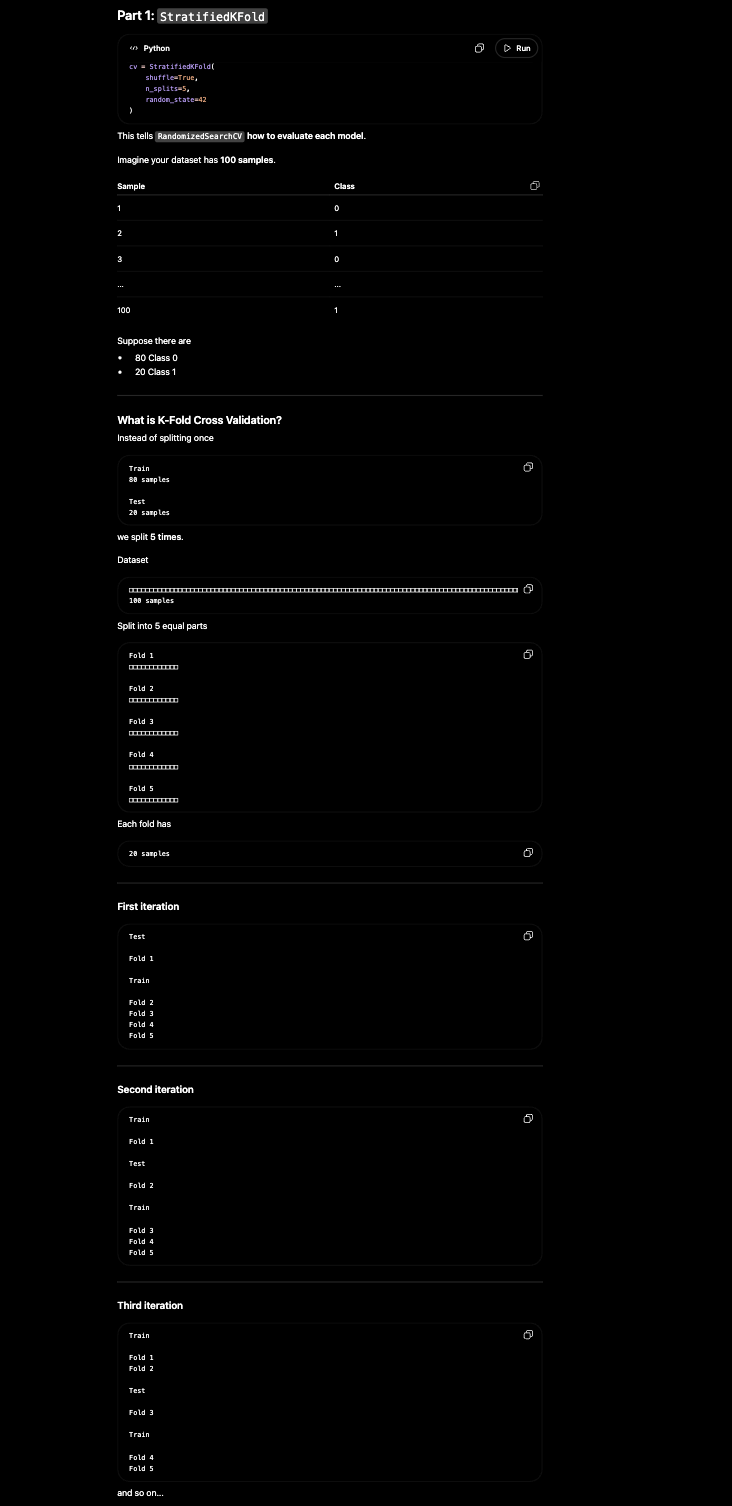

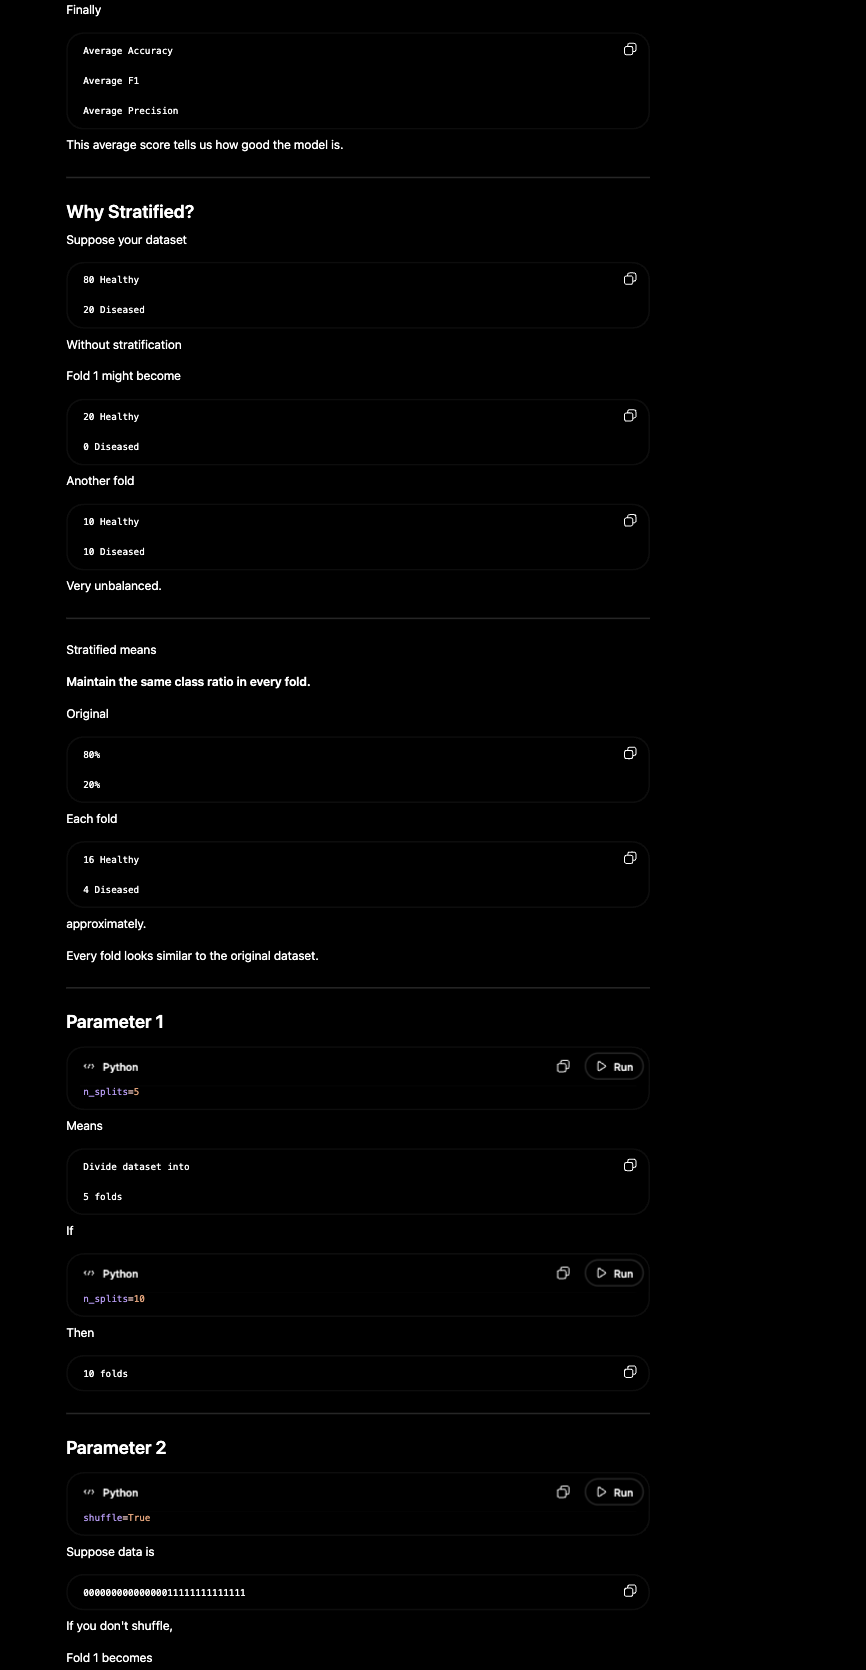

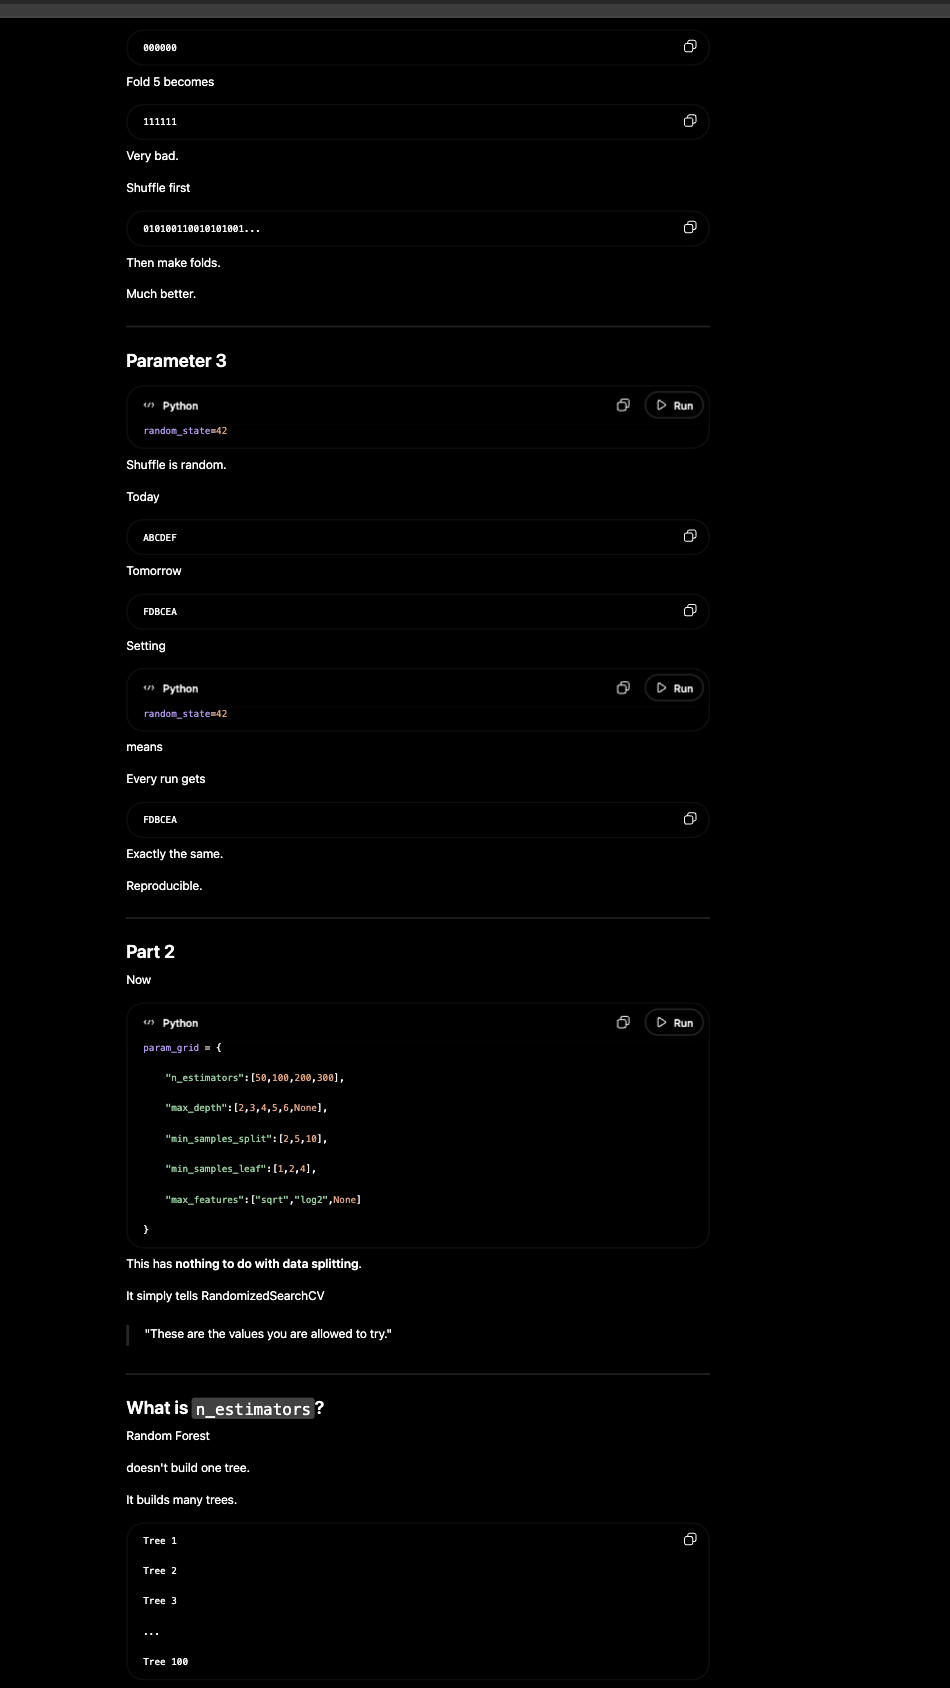

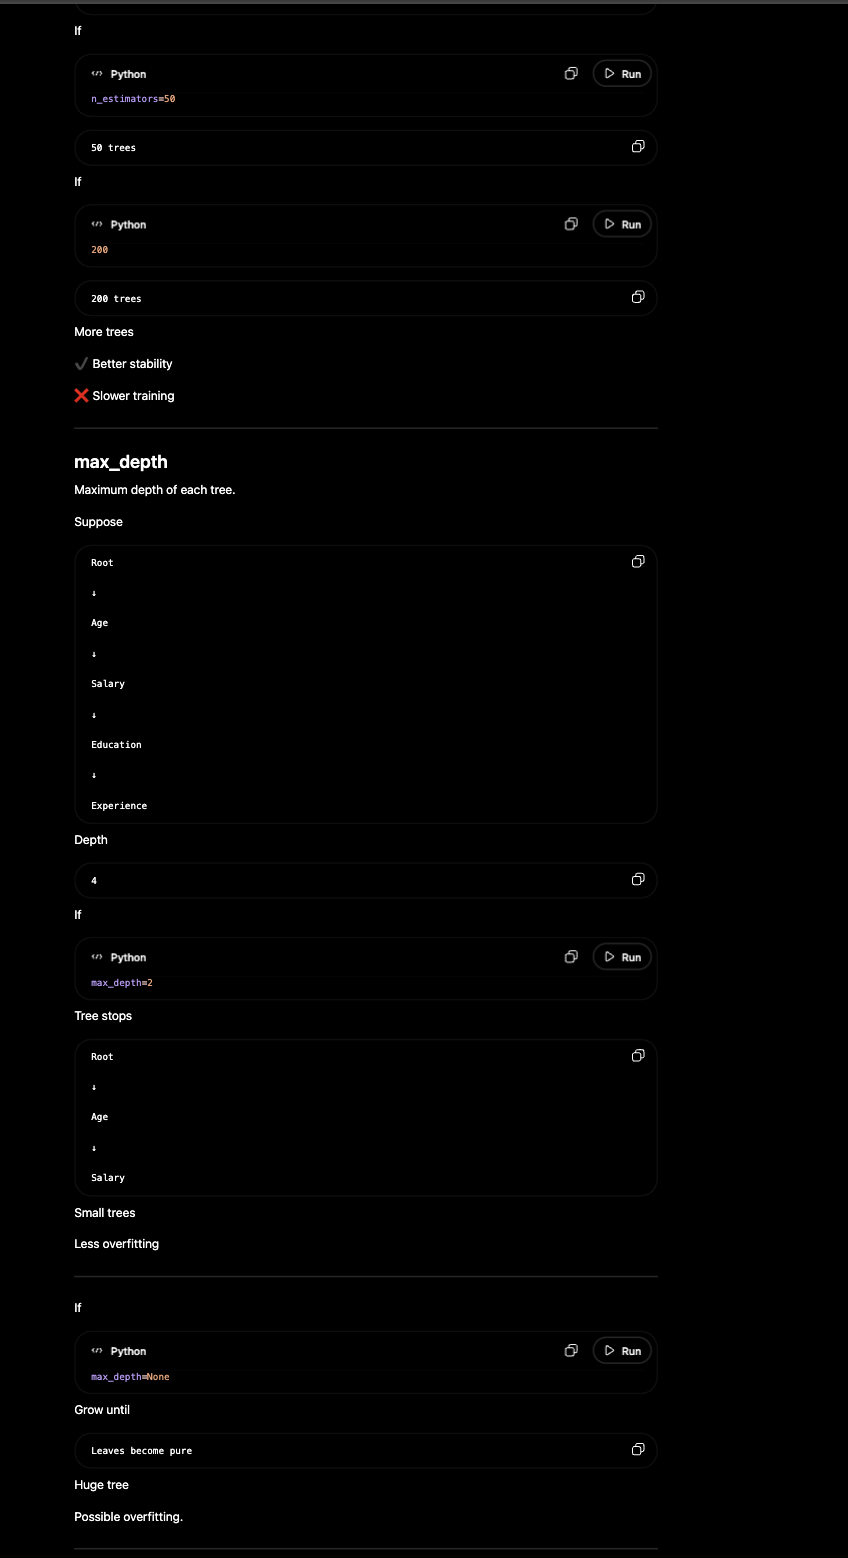

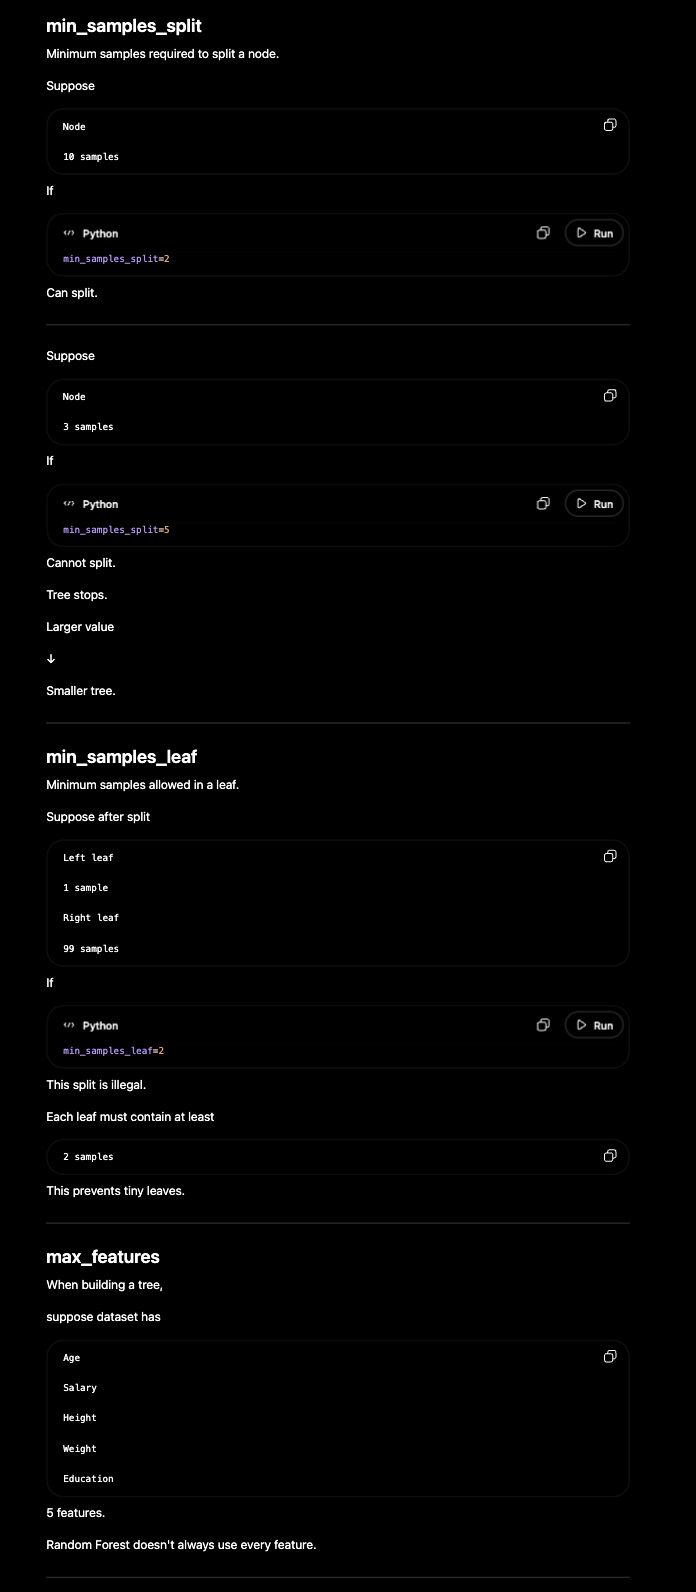

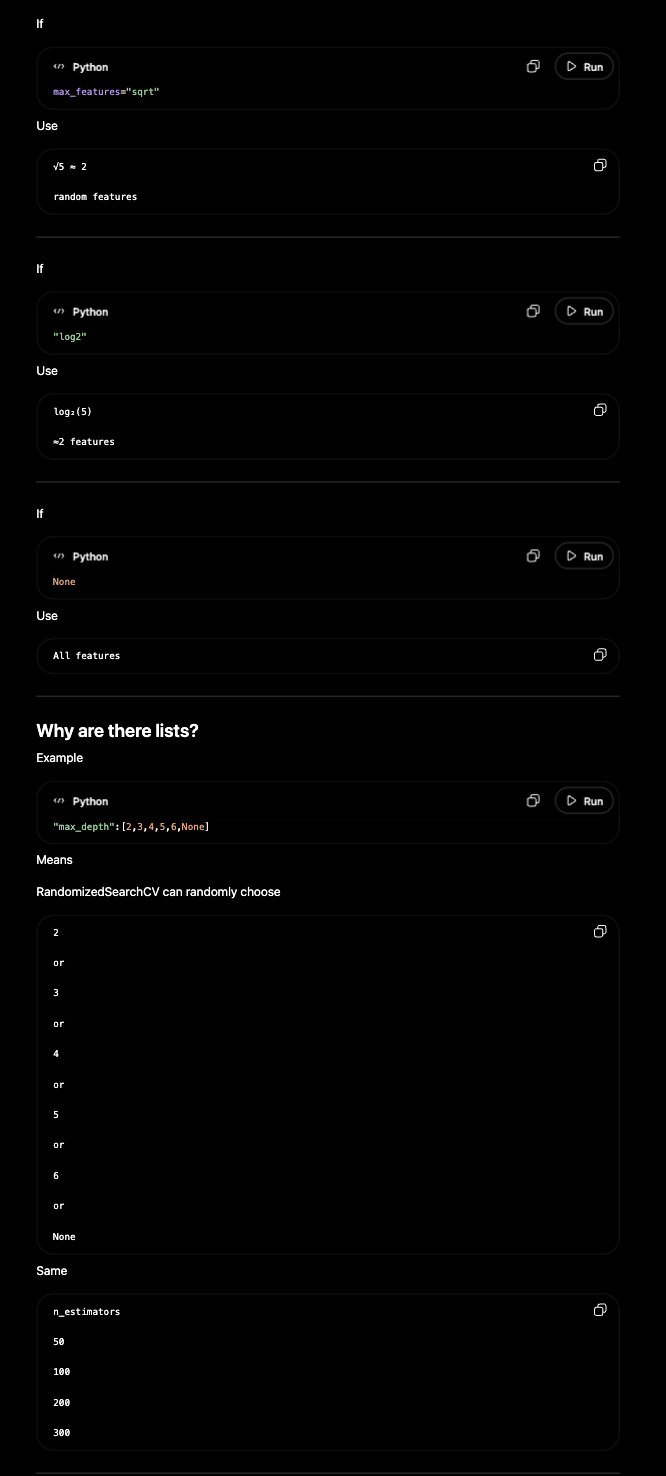

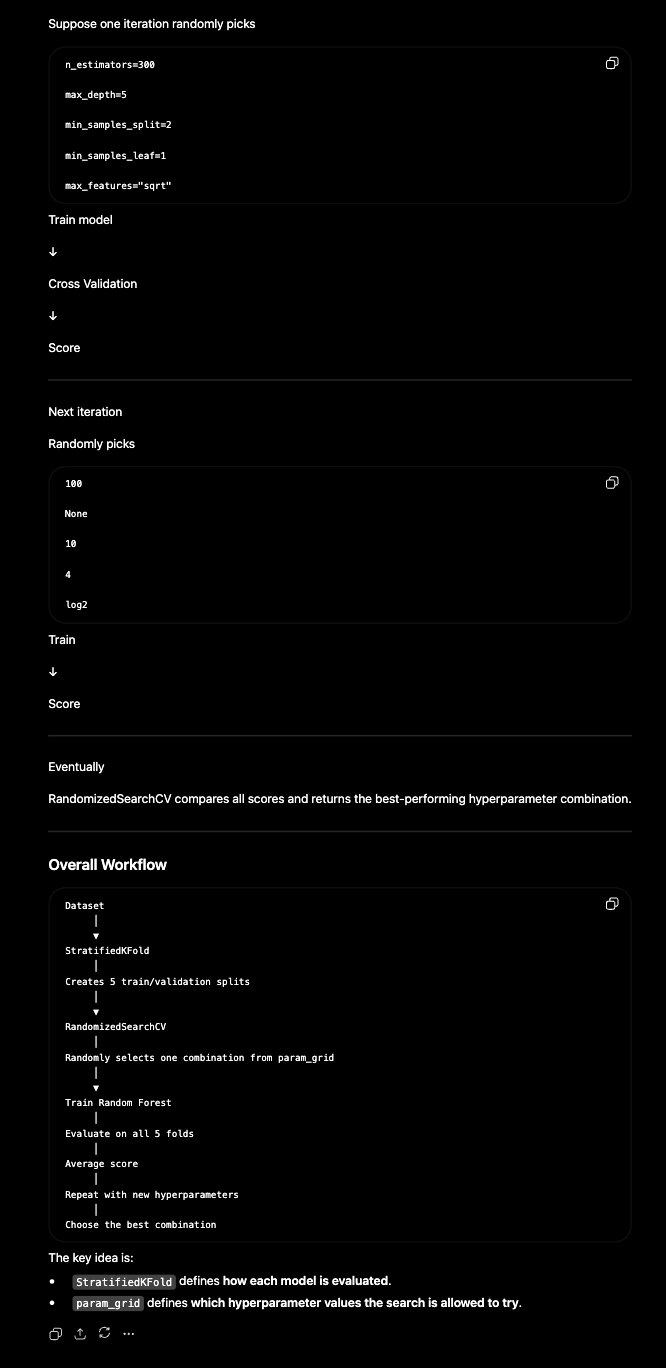

In [44]:
cv=StratifiedKFold(
    shuffle=True,
    n_splits=5,
    random_state=42
)

param_grid = { "n_estimators":[50,100,200,300], "max_depth":[2,3,4,5,6,None], "min_samples_split":[2,5,10], "min_samples_leaf":[1,2,4],"max_features":["sqrt","log2",None] }

## Resume from checkpoint

In [49]:
checkpoint_path='rf_checkpoint.pkl'
import os
if os.path.exists(checkpoint_path):
    print("resuming from checkpoint...\n")
    all_results=joblib.load(checkpoint_path)
else:
    print("checkpoint doesn't exist")
    all_results=[]

checkpoint doesn't exist


## Batch Search

in each iteration, randomized searchcv chooses one set of hyperparameters.. for 100 iterations, there will be 100 such combinations and it will give the best set of hyperparameters


Instead of 100 iterations, we perform 5 batches, 20 iterations each...  

1 batch -> 20 iterations, therefore in 10 batches there will be 100 iterations

The batches are NOT batches of your dataset.

They are batches of hyperparameter search.

Let's break it down.

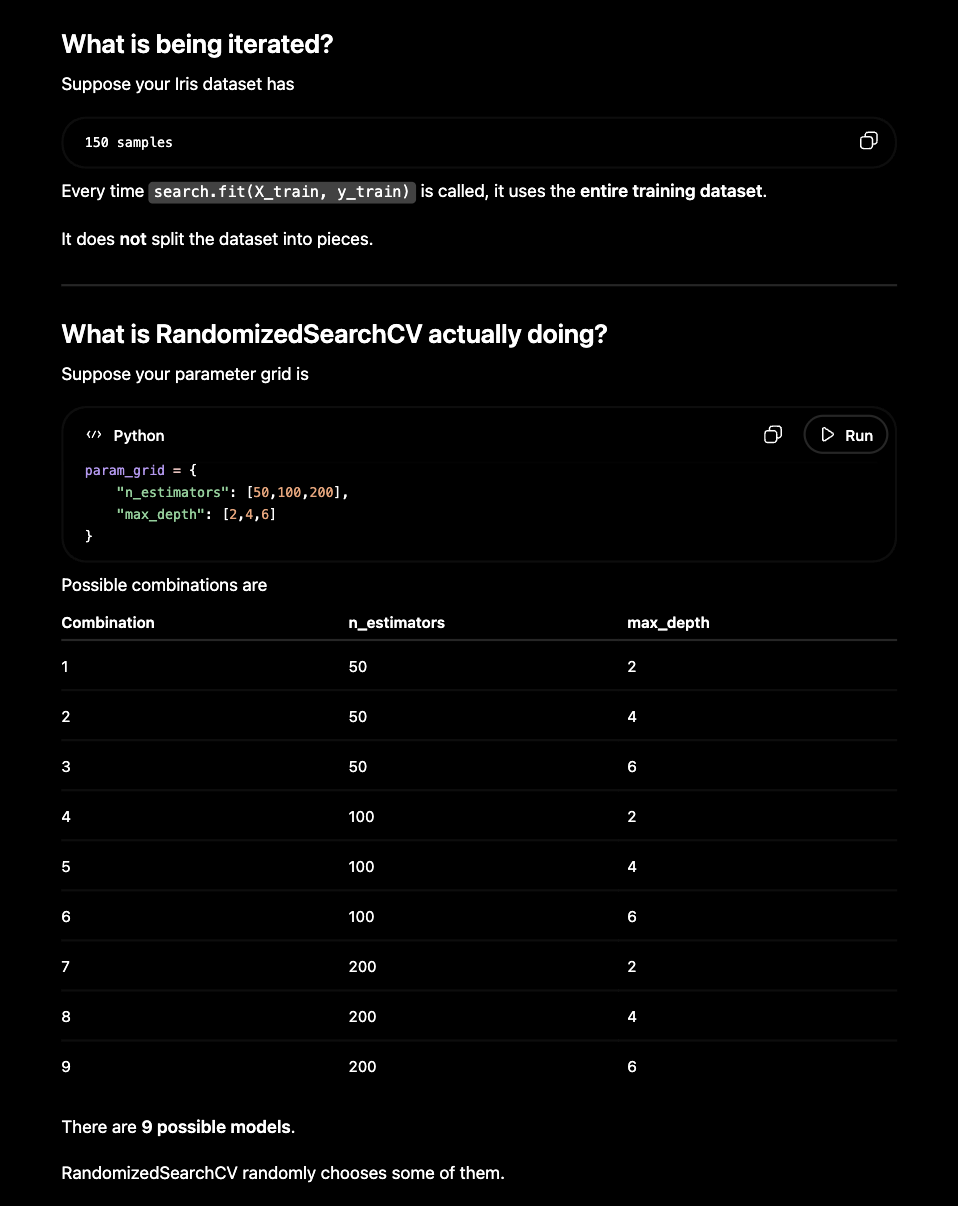

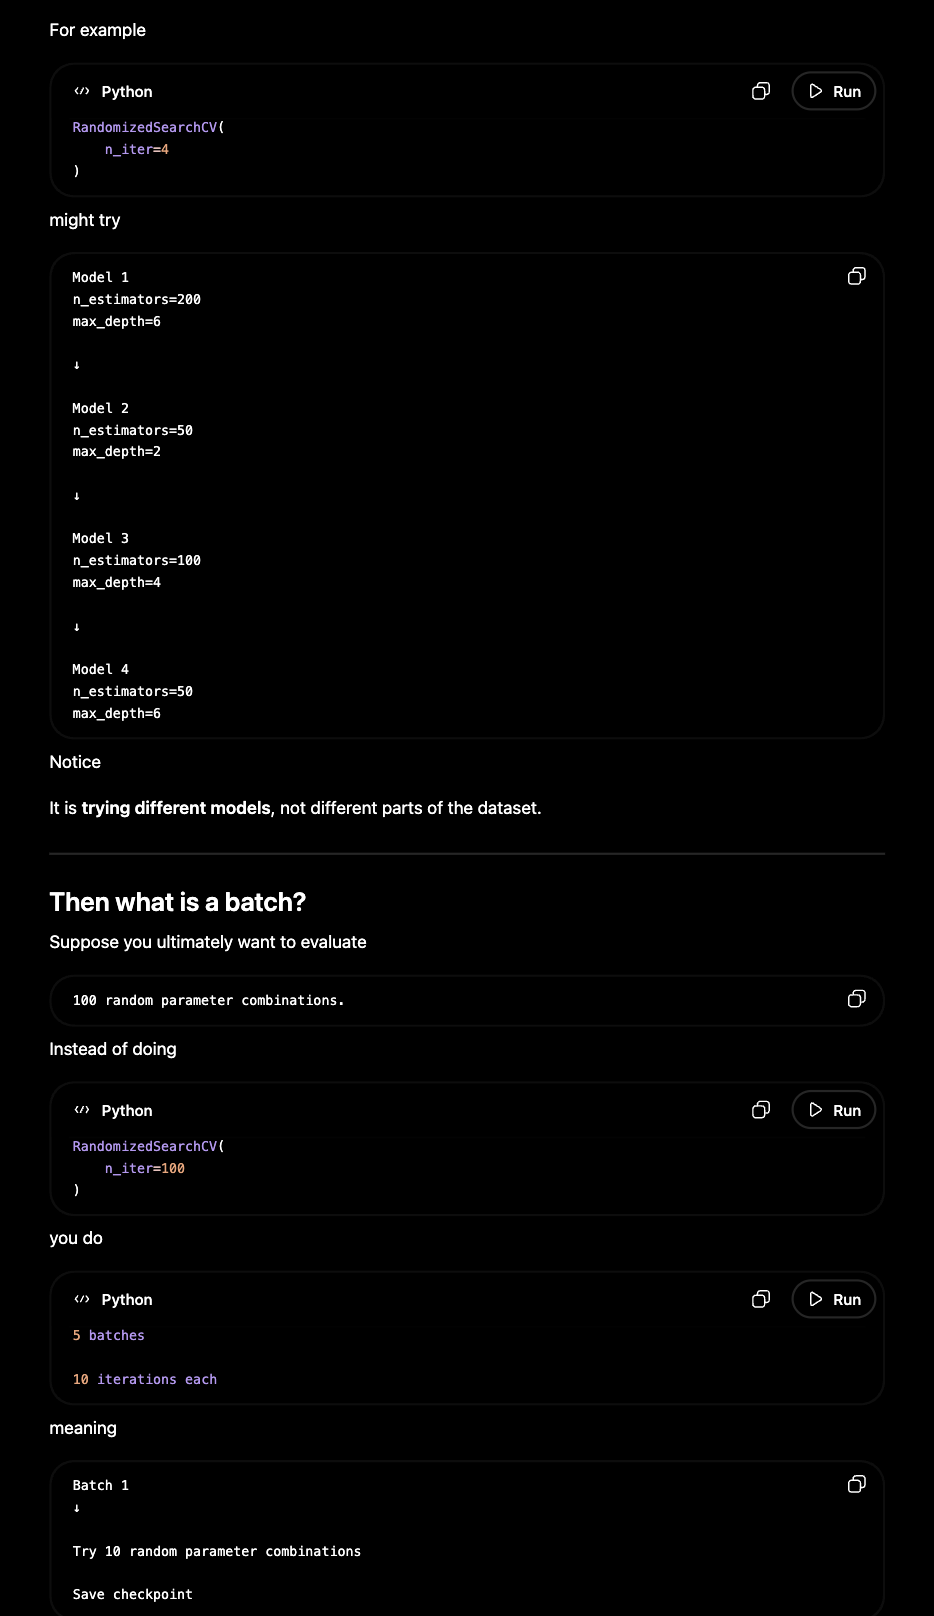

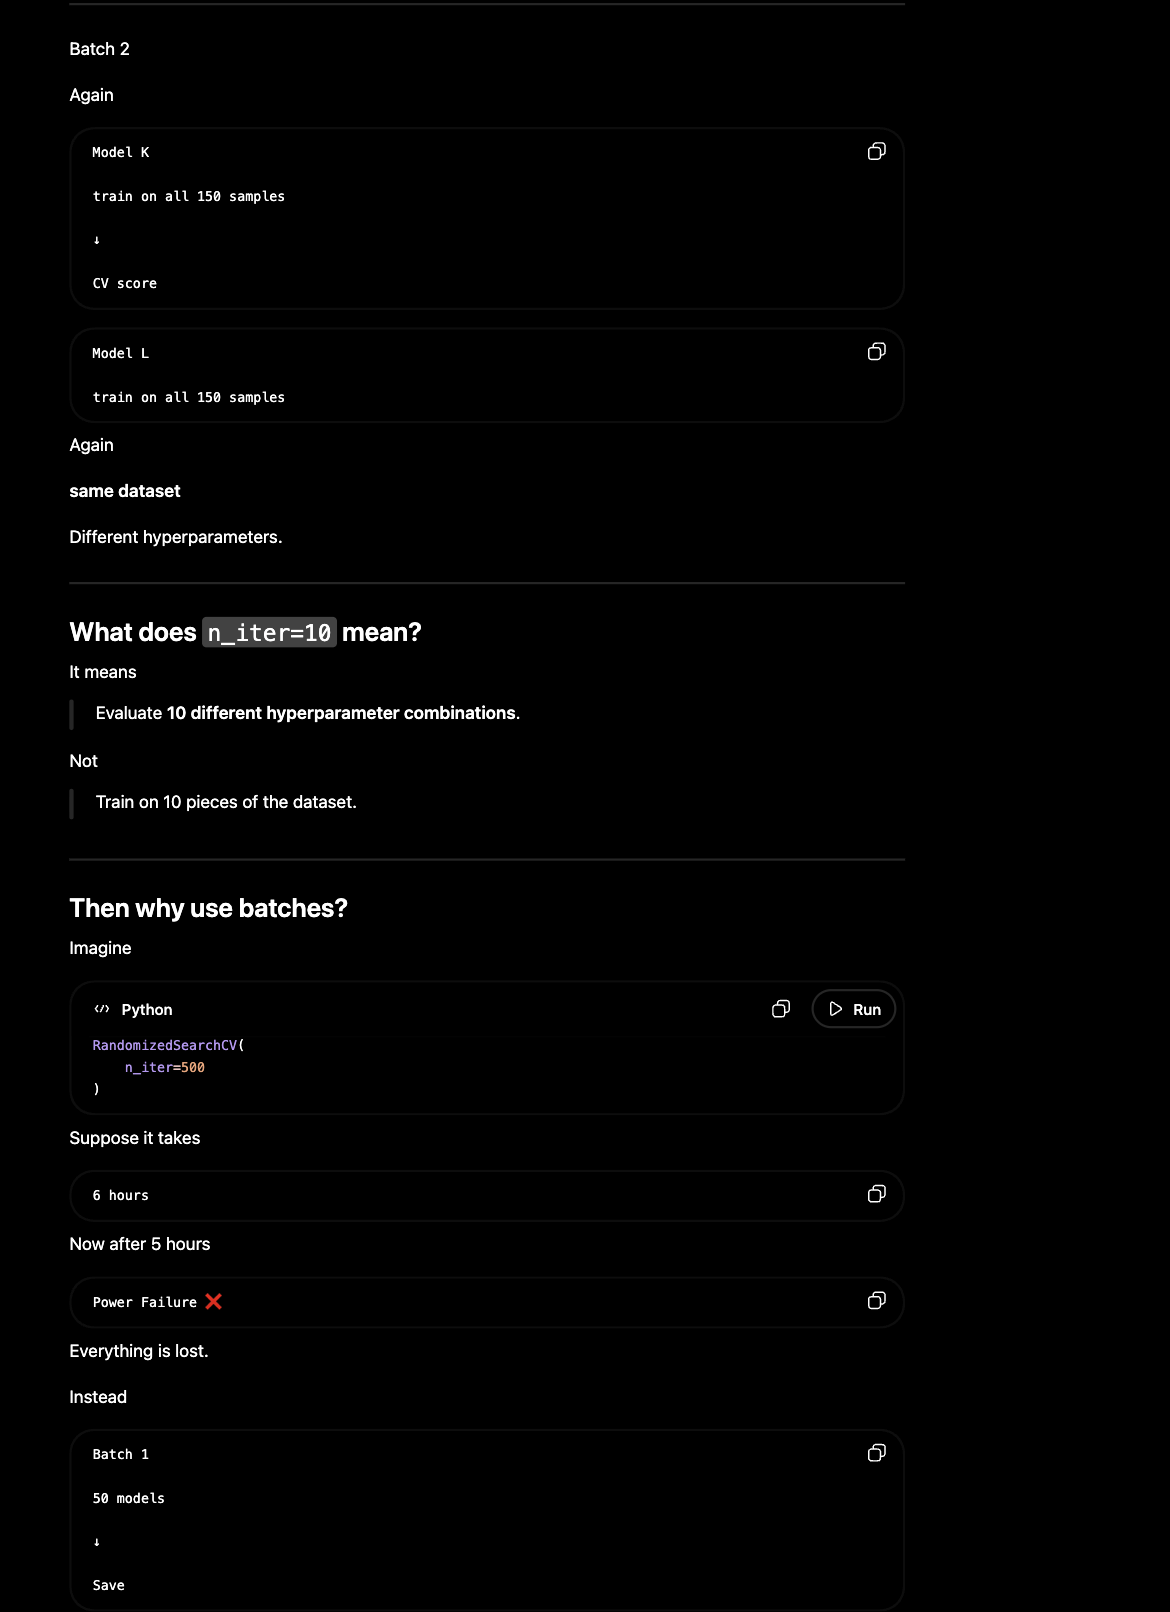

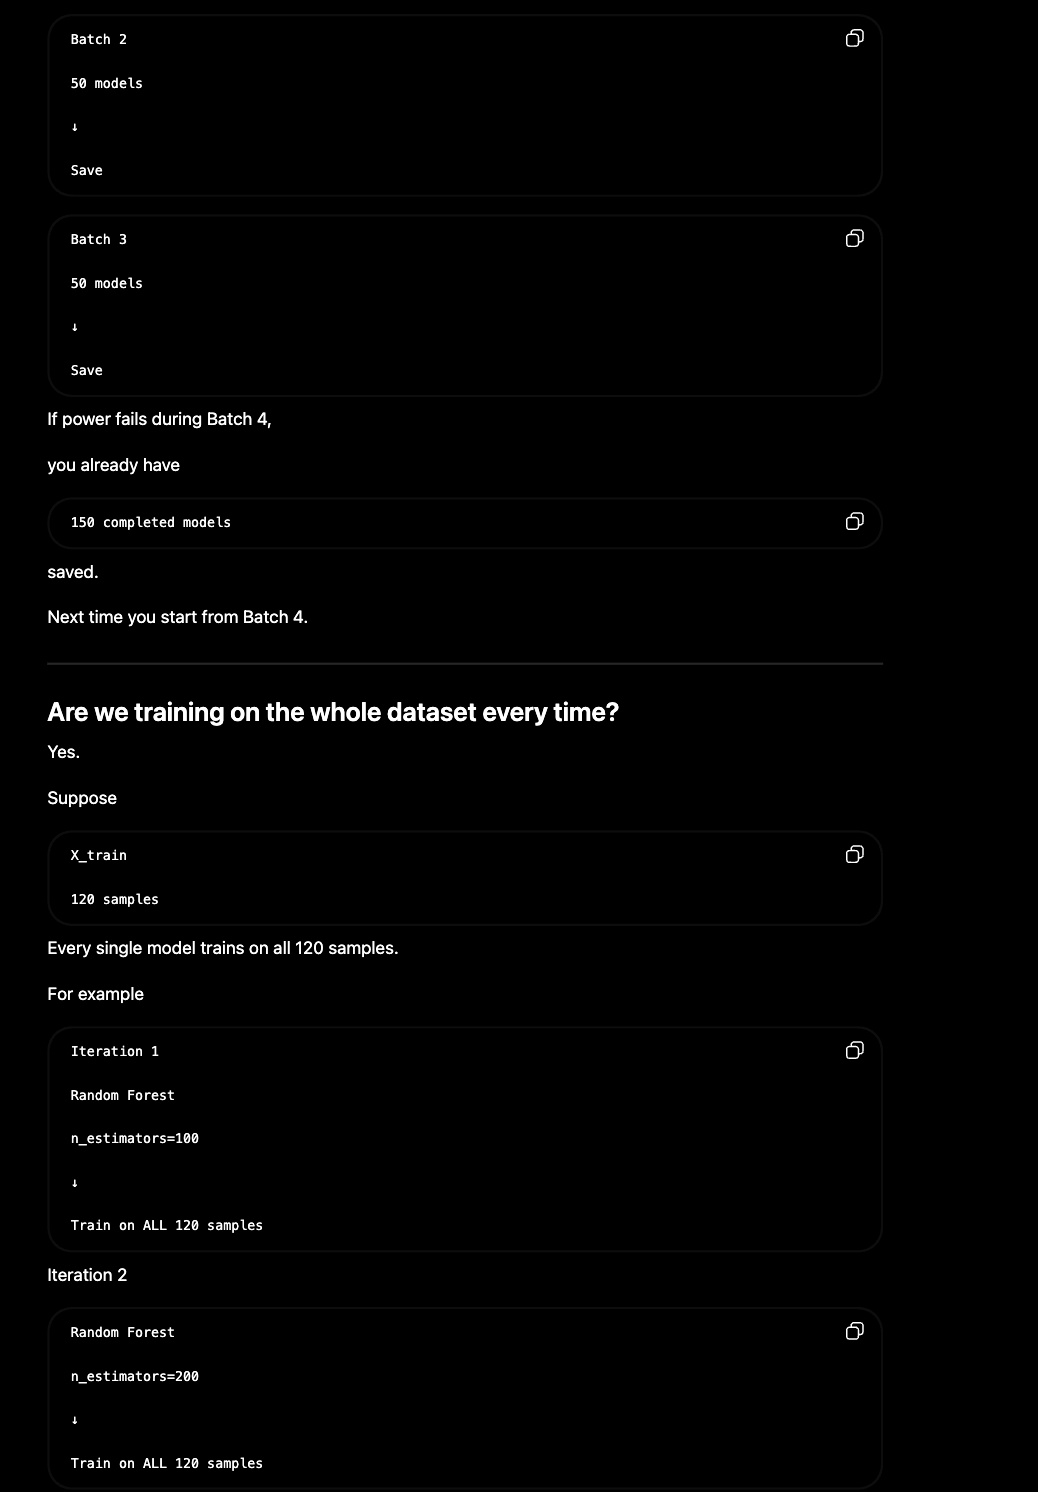

RandomizedSearchCV.fit() absolutely trains models. Cross-validation is how it trains and evaluates them.

Here's what happens when you call:

search.fit(X_train, y_train)

Internally, RandomizedSearchCV does the following:

Randomly selects n_iter hyperparameter combinations from param_grid.

For each combination:Creates a new RandomForestClassifier with those hyperparameters, Performs cross-validation.

In each CV fold:
Trains the model on the training folds, Evaluates it on the validation fold.

Computes the average validation score across all folds. Chooses the best hyperparameter combination.

Refits a final best model on the entire X_train dataset using the best hyperparameters (because refit=True by default).

When you call:

search.fit(X_train, y_train)

RandomizedSearchCV performs two tasks:

1. Finds the best hyperparameters

It randomly samples hyperparameter combinations and evaluates each one using cross-validation.

For example:

param_grid = {"n_estimators": [100, 200, 300],"max_depth": [5, 10, None]}

It might try combinations like:

n_estimators=100, max_depth=5

n_estimators=300, max_depth=None

n_estimators=200, max_depth=10

...

2. Trains models

To evaluate each hyperparameter combination, it must train a model.

If cv=5 and n_iter=10:

10 hyperparameter combinations
5 folds each

It trains:

10 × 5 = 50 models

Then, because refit=True by default, it trains one final model on the entire training dataset using the best hyperparameters.

So what does search.fit() actually do?
search.fit(X_train, y_train)

        │
        ▼
Randomly choose hyperparameter combinations
        │
        ▼
Train models using cross-validation
        │
        ▼
Compute average CV score
        │
        ▼
Select best hyperparameters
        │
        ▼
Train one final model on all of X_train (refit=True)




After search.fit()

You can access:

search.best_params_       # Best hyperparameters
search.best_score_        # Best CV score
search.best_estimator_    # Final trained model

Notice that search.best_estimator_ is already trained, so you can immediately do:

y_pred = search.predict(X_test)

without calling .fit() again.

In summary: search.fit() trains many models during cross-validation to find the best hyperparameters, and then (by default) trains one final model using those best hyperparameters on the full training set.

It trains:

10  (10 different hyperparameter combination)  × 5 (models with same hyperparameters) = 50 
           
Then, because refit=True by default, it trains one final model on the entire training dataset using the best hyperparameters.

he 5 folds do not mean one model is reused. Instead, a new model is trained for each fold.

Let's take an example.

Suppose you have 100 samples and cv=5.

The data is split into 5 folds:

Fold 1 : 20 samples
Fold 2 : 20 samples
Fold 3 : 20 samples
Fold 4 : 20 samples
Fold 5 : 20 samples

Now consider just one hyperparameter combination, for example:

n_estimators=100, max_depth=10

Cross-validation performs:

Fold	Training Data	Validation Data	New Model?
1	Folds 2+3+4+5 (80 samples)	Fold 1 (20 samples)	✅ Model 1
2	Folds 1+3+4+5	Fold 2	✅ Model 2
3	Folds 1+2+4+5	Fold 3	✅ Model 3
4	Folds 1+2+3+5	Fold 4	✅ Model 4
5	Folds 1+2+3+4	Fold 5	✅ Model 5

Notice that the training data changes in every fold.

but note all the 5 models have the same hyperparameters...

So for one hyperparameter combination, you get:

Train Model 1:Evaluate on Fold 1

Train Model 2:Evaluate on Fold 2

Train Model 3:Evaluate on Fold 3

Train Model 4:Evaluate on Fold 4

Train Model 5:Evaluate on Fold 5

During 5-fold cross-validation, scikit-learn does something conceptually like this:

# Fold 1
model1 = RandomForestClassifier(n_estimators=100, max_depth=10)
model1.fit(train_fold_1)

# Fold 2
model2 = RandomForestClassifier(n_estimators=100, max_depth=10)
model2.fit(train_fold_2)

# Fold 3
model3 = RandomForestClassifier(n_estimators=100, max_depth=10)
model3.fit(train_fold_3)

# Fold 4
model4 = RandomForestClassifier(n_estimators=100, max_depth=10)
model4.fit(train_fold_4)

# Fold 5
model5 = RandomForestClassifier(n_estimators=100, max_depth=10)
model5.fit(train_fold_5)

Notice that it creates five separate RandomForestClassifier objects.The hyperparameters are the same.


In [62]:
N_batches=5
Iterations_per_batch=20

for batch in range(len(all_results),N_batches):
    print(f"Running Batch:{batch+1}/{N_batches}")
    search=RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        n_jobs=-1,
        verbose=2,
        cv=cv,
        param_distributions=param_grid,
        random_state=batch+42,
        n_iter=Iterations_per_batch,
        scoring='accuracy',
        refit=True ## after getting the best model it trains the model once more on the entire dataset
    )
    
    search.fit(X_train,y_train) ## finds the best hyperparameter model and then train it once more on the entire dataset bcz refit=True
    ## if refit=False then it will just find the best hyperparameter model but won't train it on the entire dataset

    all_results.append(search.cv_results_)
    joblib.dump(search.best_estimator_,f"rf_batch_{batch}.pkl")

    print("checkpoint Saved.\n")
    

## 1.search.best_params_

This gives you the best hyperparameter combination found during the search.

Example:

search.best_params_

Output:

{'n_estimators': 300,'max_depth': 20,'min_samples_split': 4}

This means RandomizedSearchCV compared many combinations and concluded that these hyperparameters gave the best average cross-validation performance.

## 2.search.best_score_

This gives the average cross-validation score of the best hyperparameters.

For example:

search.best_score_

Output:

0.9135

Since your scoring is:

scoring="accuracy"


## 3. search.best_estimator_

This is the actual trained model.

Suppose the best hyperparameters are:

{'n_estimators': 300,'max_depth': 20}

Then after selecting them, RandomizedSearchCV automatically does:

best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20
)

best_model.fit(X_train, y_train)


That trained model is stored in:

search.best_estimator_

So you can directly use it:

y_pred = search.best_estimator_.predict(X_test)

or equivalently:

y_pred = search.predict(X_test)

because RandomizedSearchCV forwards prediction calls to best_estimator_ after refitting.


verbose

The verbose parameter controls how much information is printed while the search is running.

Common values are:

verbose=0 (default): No output.

verbose=1: Prints basic progress information.

verbose=2: Prints more detailed progress, such as when each fold and parameter combination starts/finishes.
Higher values (3, 4, etc.): Even more detailed output.

For example, with: verbose=2

you might see output like:

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=10, n_estimators=200; total time=0.5s
[CV] END max_depth=20, n_estimators=100; total time=0.4s
...

This is useful for monitoring long-running searches.

n_jobs

The n_jobs parameter specifies how many CPU cores to use for parallel computation.

Common values:

n_jobs=1: Use only one CPU core (sequential execution).

n_jobs=2: Use two CPU cores.

n_jobs=-1: Use all available CPU cores.

n_jobs=-2: Use all but one CPU core.

For example:

n_jobs=-1

If your computer has 8 CPU cores, scikit-learn will try to use all 8 to evaluate different parameter combinations simultaneously, significantly speeding up the search.

## Combine All Results

In [64]:
df_results=pd.concat(
    [pd.DataFrame(r) for r in all_results],
    ignore_index=True
)
df_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.169412,0.017910,0.007098,0.001747,300,10,2,NaN,None,"{'n_estimators': 300, 'min_samples_split': 10,...",1.000000,0.869565,1.000000,0.954545,0.954545,0.955731,0.047638,17
1,0.037088,0.007197,0.002641,0.000961,50,5,1,sqrt,4,"{'n_estimators': 50, 'min_samples_split': 5, '...",1.000000,0.913043,1.000000,0.954545,0.954545,0.964427,0.032761,2
2,0.059229,0.007626,0.003824,0.001101,100,5,2,log2,None,"{'n_estimators': 100, 'min_samples_split': 5, ...",1.000000,0.913043,1.000000,0.954545,0.954545,0.964427,0.032761,2
3,0.056097,0.014218,0.003667,0.002103,100,10,4,NaN,5,"{'n_estimators': 100, 'min_samples_split': 10,...",1.000000,0.869565,0.954545,1.000000,0.954545,0.955731,0.047638,17
4,0.029400,0.010919,0.001954,0.000948,50,2,1,NaN,2,"{'n_estimators': 50, 'min_samples_split': 2, '...",1.000000,0.869565,1.000000,1.000000,0.954545,0.964822,0.050778,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.087288,0.021561,0.003687,0.000106,200,10,2,NaN,None,"{'n_estimators': 200, 'min_samples_split': 10,...",1.000000,0.869565,1.000000,0.954545,0.954545,0.955731,0.047638,13
96,0.100037,0.028284,0.005418,0.002112,200,2,1,NaN,6,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.956522,0.913043,1.000000,0.954545,0.954545,0.955731,0.027515,13
97,0.027539,0.003797,0.001800,0.000760,50,10,2,log2,None,"{'n_estimators': 50, 'min_samples_split': 10, ...",1.000000,0.913043,1.000000,0.954545,0.954545,0.964427,0.032761,1
98,0.027304,0.005408,0.001525,0.000580,50,2,1,NaN,None,"{'n_estimators': 50, 'min_samples_split': 2, '...",0.956522,0.913043,1.000000,0.954545,0.954545,0.955731,0.027515,13


## Find best model

In [65]:
best_idx=df_results['mean_test_score'].idxmax()
best_idx


4

In [67]:
best_row=df_results.loc[best_idx]
best_row

mean_fit_time                                                         0.0294
std_fit_time                                                        0.010919
mean_score_time                                                     0.001954
std_score_time                                                      0.000948
param_n_estimators                                                        50
param_min_samples_split                                                    2
param_min_samples_leaf                                                     1
param_max_features                                                       NaN
param_max_depth                                                            2
params                     {'n_estimators': 50, 'min_samples_split': 2, '...
split0_test_score                                                        1.0
split1_test_score                                                   0.869565
split2_test_score                                                        1.0

In [69]:
best_params=best_row["params"]
best_params

{'n_estimators': 50,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': None,
 'max_depth': 2}

In [71]:
best_score=best_row['mean_test_score']
best_score

np.float64(0.9648221343873518)

## Train Final Model

In [72]:
best_model = RandomForestClassifier(**best_params,random_state=42)
best_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

## Save Final Model

In [73]:
joblib.dump(best_model,'best_rf.pkl')

joblib.dump(best_params,'best_params.pkl')

print("\nFinal Model Saved.")


Final Model Saved.


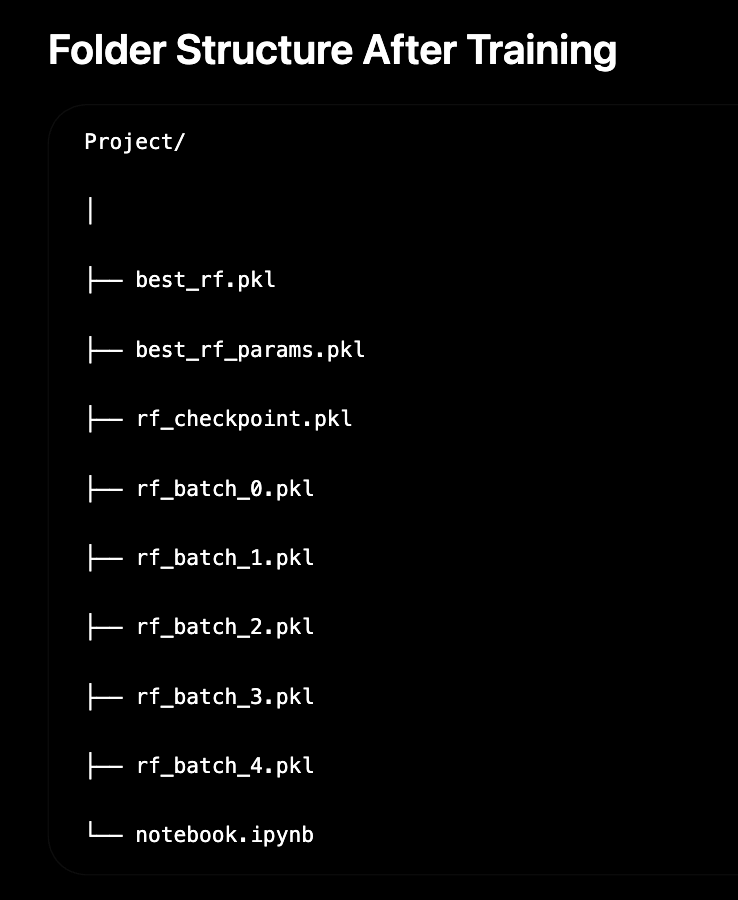

## Delete Everything

In [74]:
import os
files=['best_rf.pkl','best_params.pkl',"rf_checkpoint.pkl"]

for i in range(5): ## total 5 batches are there
    
    files.append(f"rf_batch_{i}.pkl")

for file in files:
    if os.path.exists(file):
        os.remove(file)
        print("Deleted:",file)
    else:
        print("not found",file)

Deleted: best_rf.pkl
Deleted: best_params.pkl
not found rf_checkpoint.pkl
Deleted: rf_batch_0.pkl
Deleted: rf_batch_1.pkl
Deleted: rf_batch_2.pkl
Deleted: rf_batch_3.pkl
Deleted: rf_batch_4.pkl


## Complete code

In [92]:
import os
import joblib
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)


model_path='best_rf.pkl'
param_path='best_rf_params.pkl'
checkpoint_path='rf_checkpoint.pkl'


if os.path.exists(model_path):
    print("saved model found")
    best_model=joblib.load(model_path)
    best_params=joblib.load(param_path)
    print("\n Loaded Parameters")
    print(best_params)

else:
    print("no saved model found.")
    print("starting hyperparameter search...\n")

    cv=StratifiedKFold(
    shuffle=True,
    n_splits=5,
    random_state=42
    )

    param_grid={
    'n_estimators':[50,100,200,300],
    'max_depth':[2,3,4,5,6,None],
    'min_samples_split':[2,5,10],
    'max_features':['sqrt','log2',None]
     }
    
    if os.path.exists(checkpoint_path):
        print("resuming from checkpoint...")
        checkpoint=joblib.load(checkpoint_path)
        all_results=checkpoint['results']
        best_score=checkpoint['best_score']
        best_params=checkpoint['best_params']
        best_model=checkpoint['best_model']
        
    else:
        all_results=[]
        best_score=-1
        best_params=None
        best_model=None
    
    N_batches=5
    Iterations_per_batch=10

    for batch in range(len(all_results),N_batches):
        print(f"batch{batch+1}/{N_batches}")
        rf=RandomForestClassifier(random_state=42)

        search=RandomizedSearchCV(
            estimator=rf,
            n_iter=10,
            verbose=2,
            n_jobs=-1,
            scoring='accuracy',
            param_distributions=param_grid,
            cv=cv,
            random_state=42
        )
        search.fit(X_train,y_train)
        all_results.append(search.cv_results_)

        ## check if this batch has the best model so far
        if search.best_score_ > best_score:
            best_score=search.best_score_
            best_model=search.best_estimator_
            best_params=search.best_params_

            print(f"\n new overall best score:{best_score:.4f}")
            print(best_params)

        
        ## saved checkpoint
        checkpoint={
            'results':all_results,
            'best_score':best_score,
            'best_params':best_params,
            'best_model':best_model
        }

        joblib.dump(checkpoint,checkpoint_path)

        ## save best model of current batch (optional)

        joblib.dump(
            search.best_estimator_,
            f"rf_batch_{batch+1}.pkl"
        )
        print('checkpoint saved.\n')
    
    ## save overall best model
    joblib.dump(best_model,model_path)
    joblib.dump(best_params,param_path)

    print('best cv score:',best_score)
    print('best parameters:',best_params)



## test_accuracy
y_pred=best_model.predict(X_test)

print(f'test accuracy:{accuracy_score(y_test,y_pred)}')






no saved model found.
starting hyperparameter search...

batch1/5
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_s

In [93]:
import os
files=['best_rf.pkl','best_rf_params.pkl',"rf_checkpoint.pkl"]

for i in range(5): ## total 5 batches are there
    
    files.append(f"rf_batch_{i+1}.pkl")

for file in files:
    if os.path.exists(file):
        os.remove(file)
        print("Deleted:",file)
    else:
        print("not found",file)

Deleted: best_rf.pkl
Deleted: best_rf_params.pkl
Deleted: rf_checkpoint.pkl
Deleted: rf_batch_1.pkl
Deleted: rf_batch_2.pkl
Deleted: rf_batch_3.pkl
Deleted: rf_batch_4.pkl
Deleted: rf_batch_5.pkl
